# 하이퍼 파라미터 튜닝으로 11만 점 이하 달성하기

## 
1. 캐글에 결과 제출하기 (성공!)
2. 전처리, 학습 과정을 그림과 글로 설명하기
3. **Private Score 110,000 이하** 만들기

### 
1. ID : 집을 구분하는 번호
2. date : 집을 구매한 날짜
3. price : 타겟 변수인 집의 가격
4. bedrooms : 침실의 수
5. bathrooms : 침실당 화장실 개수
6. sqft_living : 주거 공간의 평방 피트
7. sqft_lot : 부지의 평방 피트
8. floors : 집의 층수
9. waterfront : 집의 전방에 강이 흐르는지 유무 (a.k.a. 리버뷰)
10. view : 집이 얼마나 좋아 보이는지의 정도
11. condition : 집의 전반적인 상태
12. grade : King County grading 시스템 기준으로 매긴 집의 등급
13. sqft_above : 지하실을 제외한 평방 피트
14. sqft_basement : 지하실의 평방 피트
15. yr_built : 집을 지은 년도
16. yr_renovated : 집을 재건축한 년도
17. zipcode : 우편번호
18. lat : 위도
19. long : 경도
20. sqft_living15 : 근처 15 가구의 주거 공간, 평방 피트
21. sqft_lot15 : 근처 15가구의 부지, 평방 피트

# Baseline 커널 파일 실행 준비

In [9]:
# [1] 시각화 설정: 그래프를 선명하게(retina) 보고, 화면에 바로 나타나게 합니다.
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# 라이브러리, 데이터 가져오기

In [11]:
# [0] 초보자 범수님을 위한 마법의 주문! 
# 혹시 컴퓨터에 도구가 없으면 자동으로 설치해줍니다. (에러 방지용)
try:
    import xgboost
    import lightgbm
    import missingno
except ImportError:
    print("도구가 없어서 설치를 시작합니다... 잠시만 기다려주세요! 얍💢")
    !pip install xgboost lightgbm missingno

# [1] 불필요한 경고 메시지는 무시합니다. (화면을 깨끗하게!)
import warnings
warnings.filterwarnings("ignore")

# [2] 파일 경로를 다루는 도구들
import os
from os.path import join

# [3] 데이터 분석의 기본! 표(pd)와 숫자(np) 도구
import pandas as pd
import numpy as np

# [4] 빈칸을 찾아주는 돋보기 도구
import missingno as msno

# [5] 11만 점 이하로 만들어줄 '인공지능 전문가 3인방'
from sklearn.ensemble import GradientBoostingRegressor # 1번 전문가
import xgboost as xgb                                  # 2번 전문가
import lightgbm as lgb                                 # 3번 전문가

# [6] 점수를 계산하고 데이터를 나누는 도구
from sklearn.model_selection import KFold, cross_val_score

# [7] 시각화(그림)를 위한 도구
import matplotlib.pyplot as plt
import seaborn as sns

# [8] 그림을 더 선명하게(Retina) 설정하기
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

print('모든 도구가 준비되었습니다! 얍💢')

도구가 없어서 설치를 시작합니다... 잠시만 기다려주세요! 얍💢
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 5.1 MB/s eta 0:00:0000:0100:02m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 109.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 40.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [lightgbm]2/3 [lightgbm]
모든 도구가 준비되었습니다! 얍💢


In [12]:
# [1] 실제 데이터가 들어있는 폴더 경로를 정확히 지정. 얍💢
#  'unsupervised/data/data' 경로를 사용.
data_dir = os.path.join(os.getenv('HOME'), 'work/unsupervised/data/data')

# [2] 폴더 경로와 파일 이름을 합쳐서 '전체 주소'를 만듭.
train_data_path = os.path.join(data_dir, 'train.csv')
sub_data_path = os.path.join(data_dir, 'test.csv')

# [3] 경로가 잘 만들어졌는지 화면에 찍어봅.
print(f"학습 데이터 경로: {train_data_path}")
print(f"테스트 데이터 경로: {sub_data_path}")

# [4] 실제로 파일이 그 자리에 있는지 확인하고 데이터를 불러옵.
data = pd.read_csv(train_data_path)
sub = pd.read_csv(sub_data_path)

print("\n✅ 데이터 불러오기 성공! 얍💢")
print(f"공부할 데이터 개수: {data.shape}")

학습 데이터 경로: /home/jovyan/work/unsupervised/data/data/train.csv
테스트 데이터 경로: /home/jovyan/work/unsupervised/data/data/test.csv

✅ 데이터 불러오기 성공! 얍💢
공부할 데이터 개수: (15035, 21)


# 데이터 이해하기

In [13]:
# [1] 공부할 데이터(train) 불러오기. 얍💢
data = pd.read_csv(train_data_path)

# [2] 시험 볼 데이터(sub) 불러오기. 확인함.
sub = pd.read_csv(sub_data_path)

# [3] 데이터 크기(줄, 칸) 확인. 
print(f'train data dim : {data.shape}')
print(f'sub data dim : {sub.shape}')

# [4] 데이터 어떻게 생겼는지 앞부분 확인. 
data.head()

train data dim : (15035, 21)
sub data dim : (6468, 20)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


In [14]:
# [1] 정답인 집값(price)만 y라는 변수에 따로 저장. 확인함. 💢
y = data['price']

# [2] 공부할 문제집(data)에서 정답은 삭제. 
del data['price']

# [3] 문제집에 정답 칸이 잘 사라졌는지 항목 확인. 
print(data.columns)

Index(['id', 'date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')


In [15]:
# [1] 공부할 데이터(train)의 줄 개수 기억. 나중에 자를 때 써야 함. 💢
train_len = len(data)

# [2] 문제집(data)이랑 시험지(sub)를 세로로 합치기. 
data = pd.concat((data, sub), axis=0)

# [3] 합쳐진 전체 데이터 줄 개수 확인. 
print(len(data))

21503


In [16]:
# [1] 합쳐진 데이터(data) 앞부분 5줄 출력. 💢
data.head()

# [2] 항목들(id, date, bedrooms 등) 잘 있는지 확인. 
# [3] price는 아까 지워서 안 나와야 함. 확인함.

,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,20141013T000000,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,20150225T000000,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,20150218T000000,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,20140627T000000,3,2.25,1715,6819,2.0,0,0,3,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,20150115T000000,3,1.50,1060,9711,1.0,0,0,3,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


<Axes: >

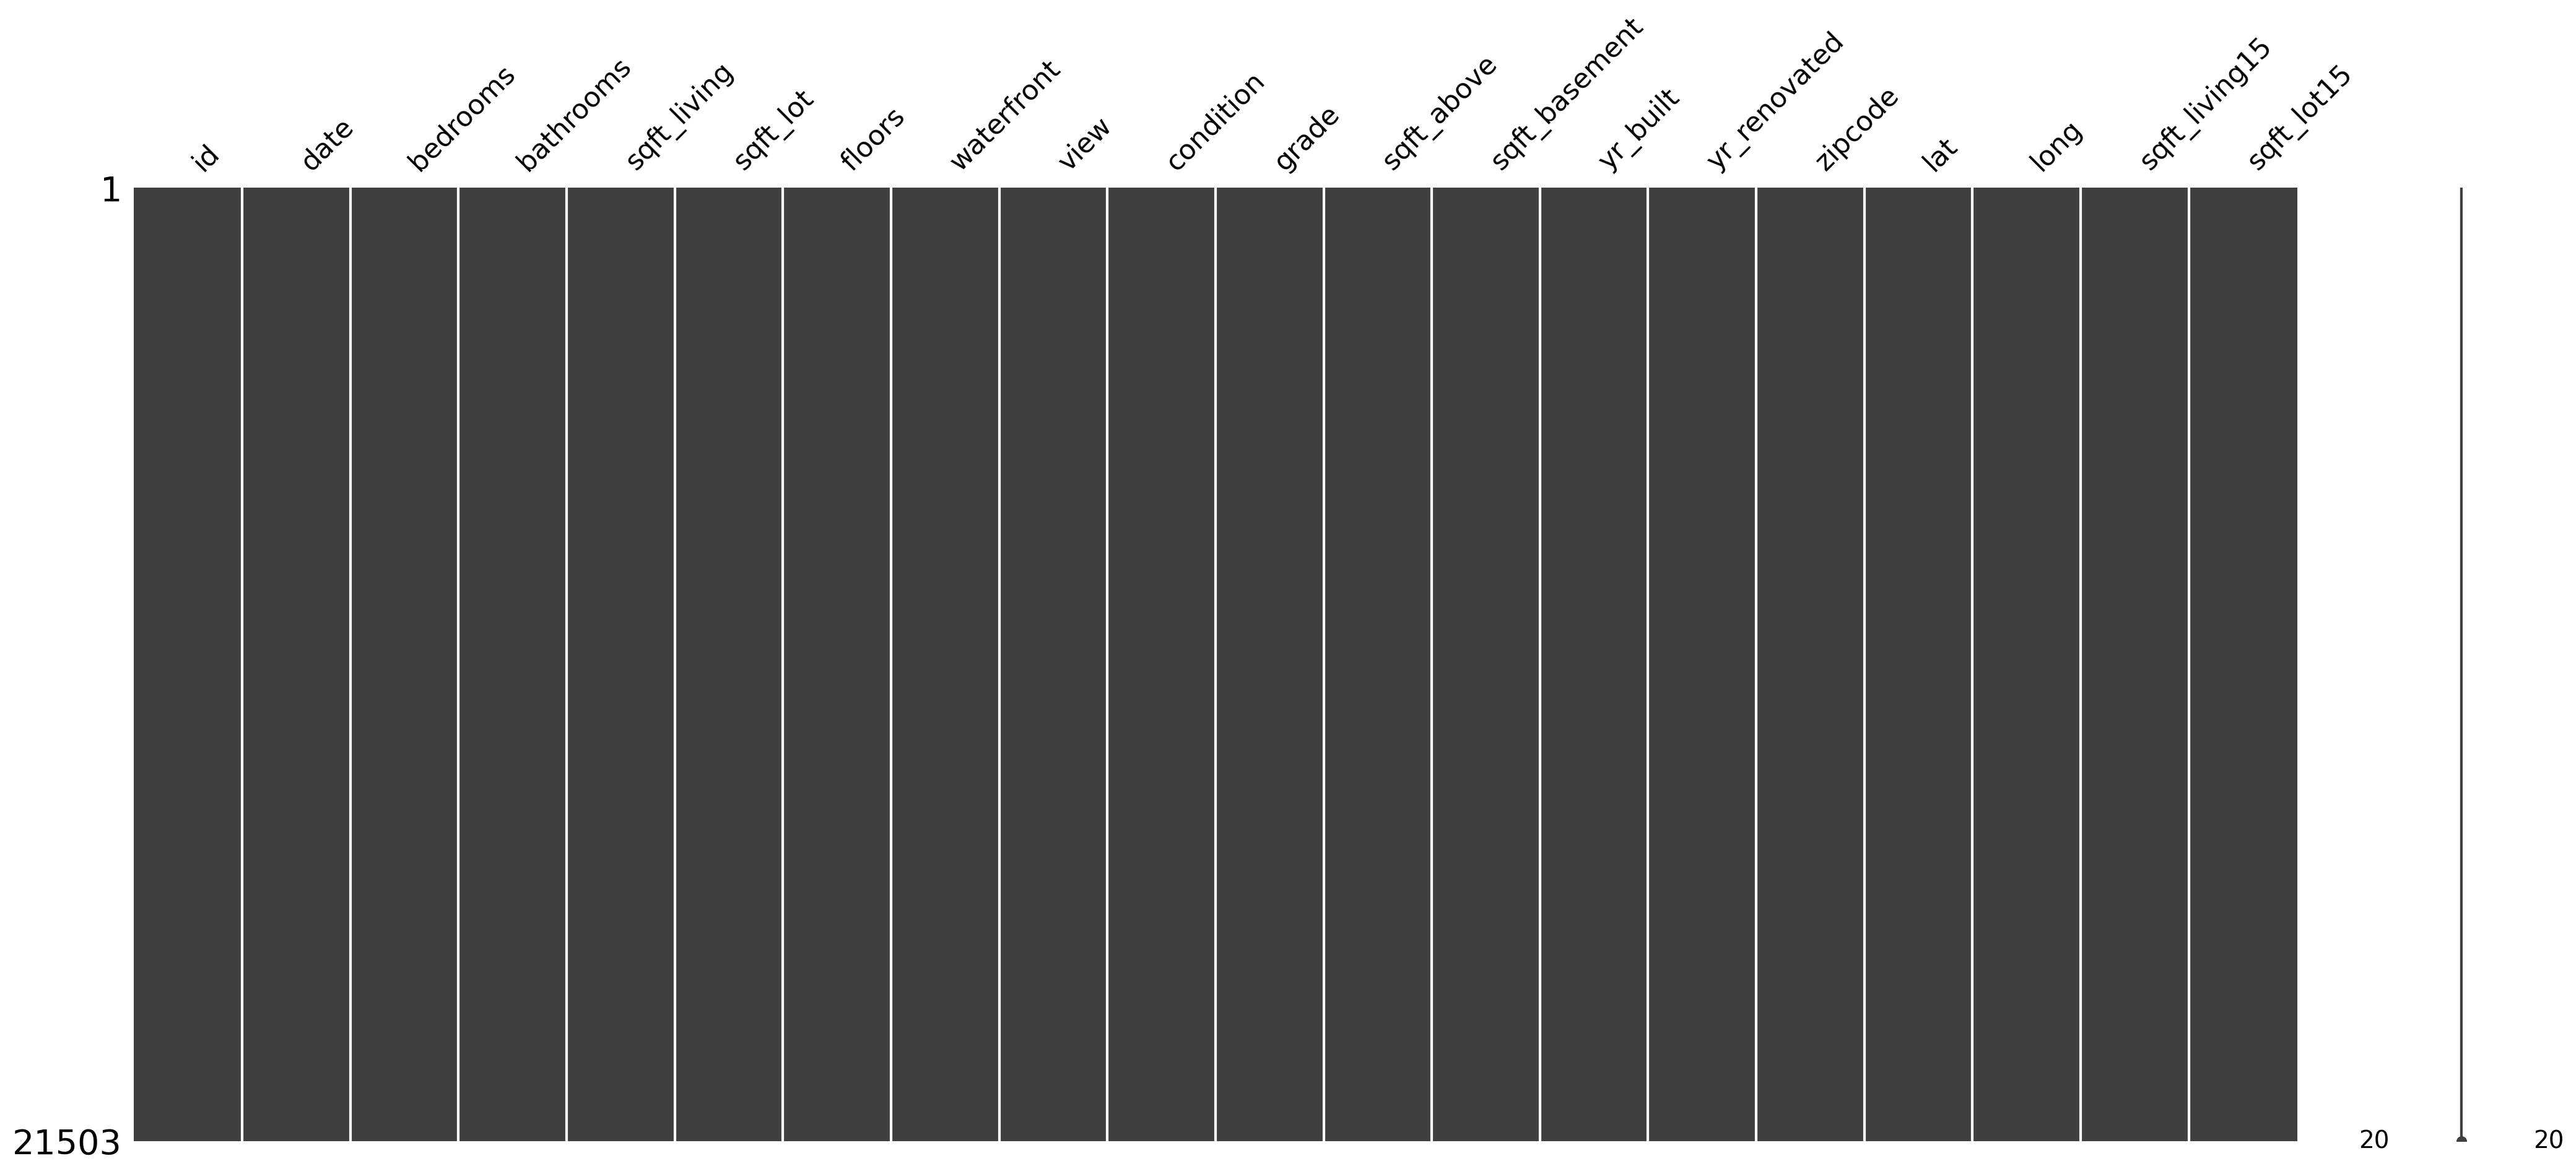

In [17]:
# [1] 데이터에 빈틈이 있는지 그림(매트릭스)으로 확인. 얍💢
msno.matrix(data)

# [2] 화면에 그림 출력. 확인함.

In [18]:
# [1] id 컬럼에 빈칸(null)이 있는지 하나하나 검사. 얍💢
null_check = pd.isnull(data['id'])

# [2] 결과 화면에 출력. 확인함.
print(null_check)

0       False
1       False
2       False
3       False
4       False
        ...  
6463    False
6464    False
6465    False
6466    False
6467    False
Name: id, Length: 21503, dtype: bool


In [19]:
# 2. 결측치인 데이터만 뽑아냅니다.
null_data = data.loc[null_check, 'id']
null_data.head()

Series([], Name: id, dtype: int64)

In [20]:
# [1] 빈칸인 데이터만 따로 뽑아내기. 얍💢
null_data = data[null_check]

# [2] 빈칸 개수 세서 화면에 출력. 확인함.
print(f'id: {len(null_data.values)}')

id: 0


In [21]:
# [1] id 칸에서 빈칸(null)인 것만 골라낸 뒤 개수(len) 세기. 얍💢
# [2] f-string 대신 format 써서 안전하게 출력. 확인함.
print('{} : {}'.format('id', len(data.loc[pd.isnull(data['id']), 'id'].values)))

id : 0


In [22]:
# [1] 모든 컬럼(columns) 돌면서 빈칸 개수 찍기. 얍💢
for c in data.columns:
    print('{} : {}'.format(c, len(data.loc[pd.isnull(data[c]), c].values)))

# [2] 전부 0 나오는지 확인. 확인함.

id : 0
date : 0
bedrooms : 0
bathrooms : 0
sqft_living : 0
sqft_lot : 0
floors : 0
waterfront : 0
view : 0
condition : 0
grade : 0
sqft_above : 0
sqft_basement : 0
yr_built : 0
yr_renovated : 0
zipcode : 0
lat : 0
long : 0
sqft_living15 : 0
sqft_lot15 : 0


In [23]:
# [1] 시험지(sub) 부분의 ID만 따로 챙기기. 얍💢
sub_id = data['id'][train_len:]

# [2] 공부할 문제집(data) 전체에서 ID 칸 삭제. 
del data['id']

# [3] 문제집에 ID 칸 사라졌는지 항목 확인. 확인함. 
print(data.columns)

Index(['date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')


In [24]:
# [1] 날짜(date) 칸에서 앞의 6글자만 남기고 자르기. 얍💢
# [2] lambda 써서 한 줄씩 싹 다 적용. 확인함.
data['date'] = data['date'].apply(lambda x : str(x[:6]))

# [3] 날짜 예쁘게 깎였는지 앞부분 확인. 
data.head()

,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,201410,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,201502,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,201502,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,201406,3,2.25,1715,6819,2.0,0,0,3,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,201501,3,1.50,1060,9711,1.0,0,0,3,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


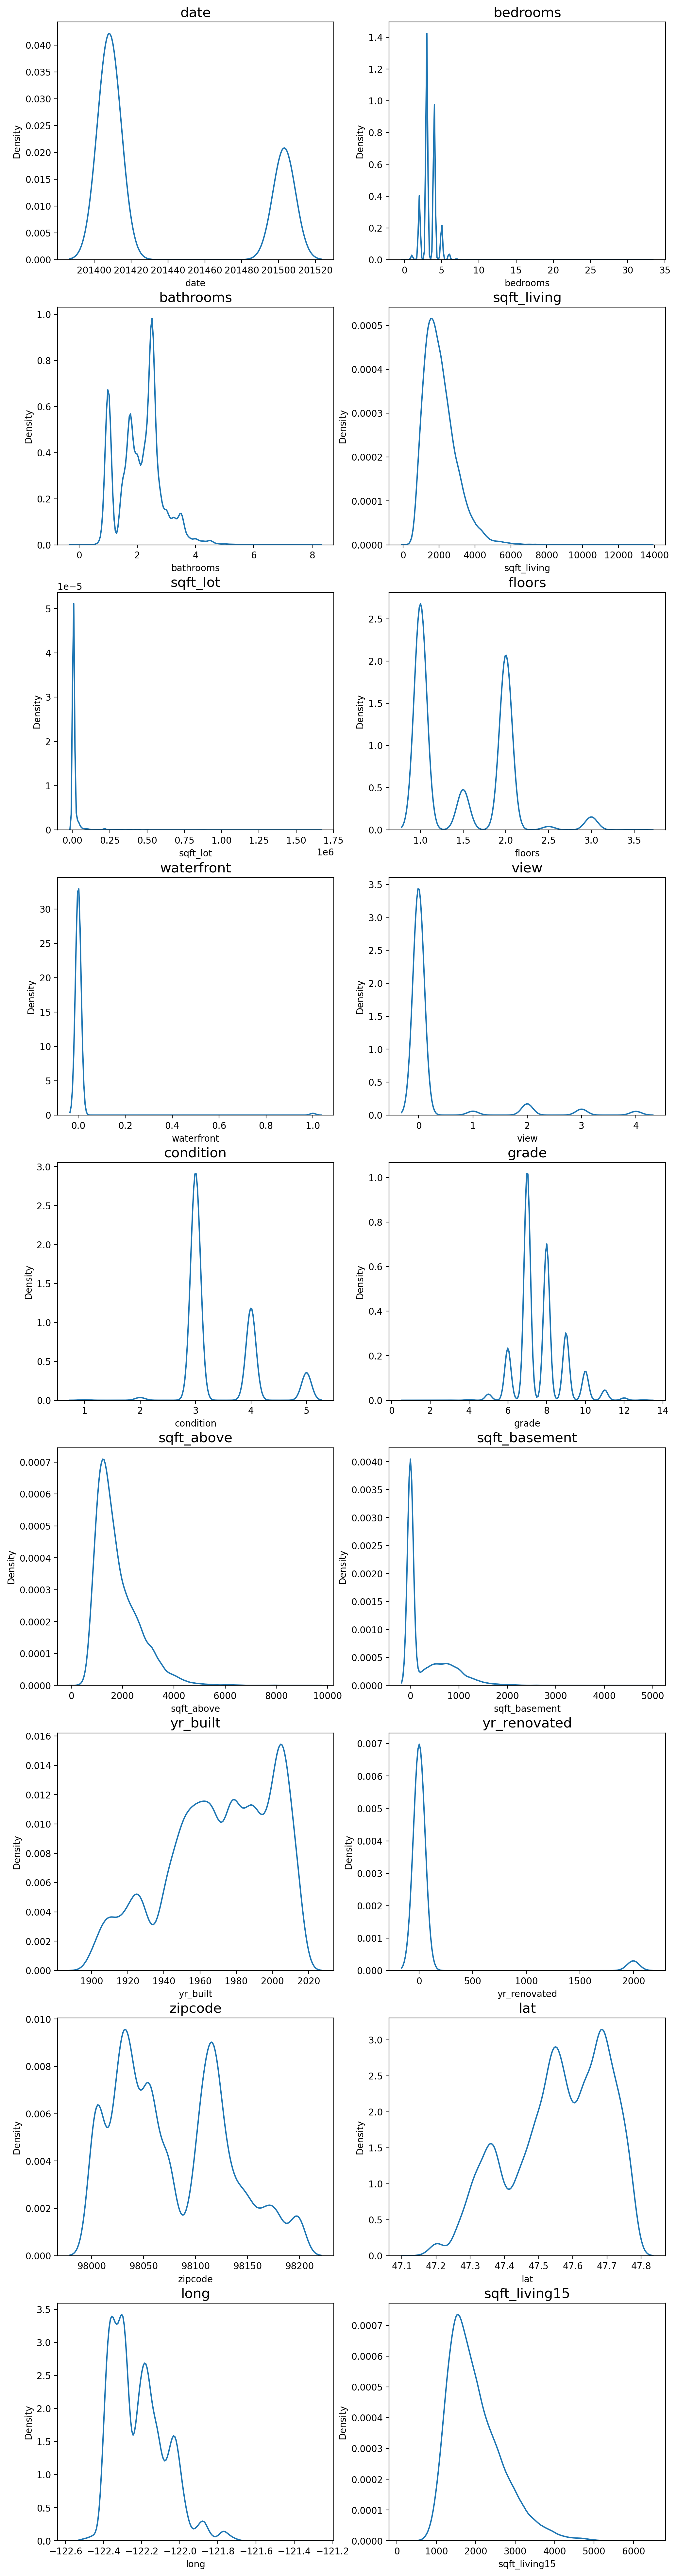

In [26]:
# [1] 9행 2열짜리 큰 그림판. 얍💢
fig, ax = plt.subplots(9, 2, figsize=(12, 50))

count = 0
columns = data.columns

for row in range(9):
    for col in range(2):
        # [2] 핵심 수정: pd.to_numeric을 써서 강제로 숫자로 바꿔서 그리기! 💢
        # 글자로 된 'date'도 이제 숫자로 인식해서 그래프 그려줌. 확인함.
        sns.kdeplot(data=pd.to_numeric(data[columns[count]]), ax=ax[row][col])
        
        # [3] 제목 달기. 💢
        ax[row][col].set_title(columns[count], fontsize=15)
        
        count += 1
        if count == len(columns):
            break

In [27]:
# [1] 그림 보고 너무 쏠려있던 항목들만 따로 목록 만들기. 얍💢
skew_columns = ['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_lot15', 'sqft_living15']

# [2] 반복문 돌면서 로그 변환(log1p) 적용. 💢
# log1p는 0이 있어도 에러 안 나게 해주는 똑똑한 도구임. 확인함.
for c in skew_columns:
    data[c] = np.log1p(data[c].values)

print('데이터 변환 완료! 얍💢')

데이터 변환 완료! 얍💢


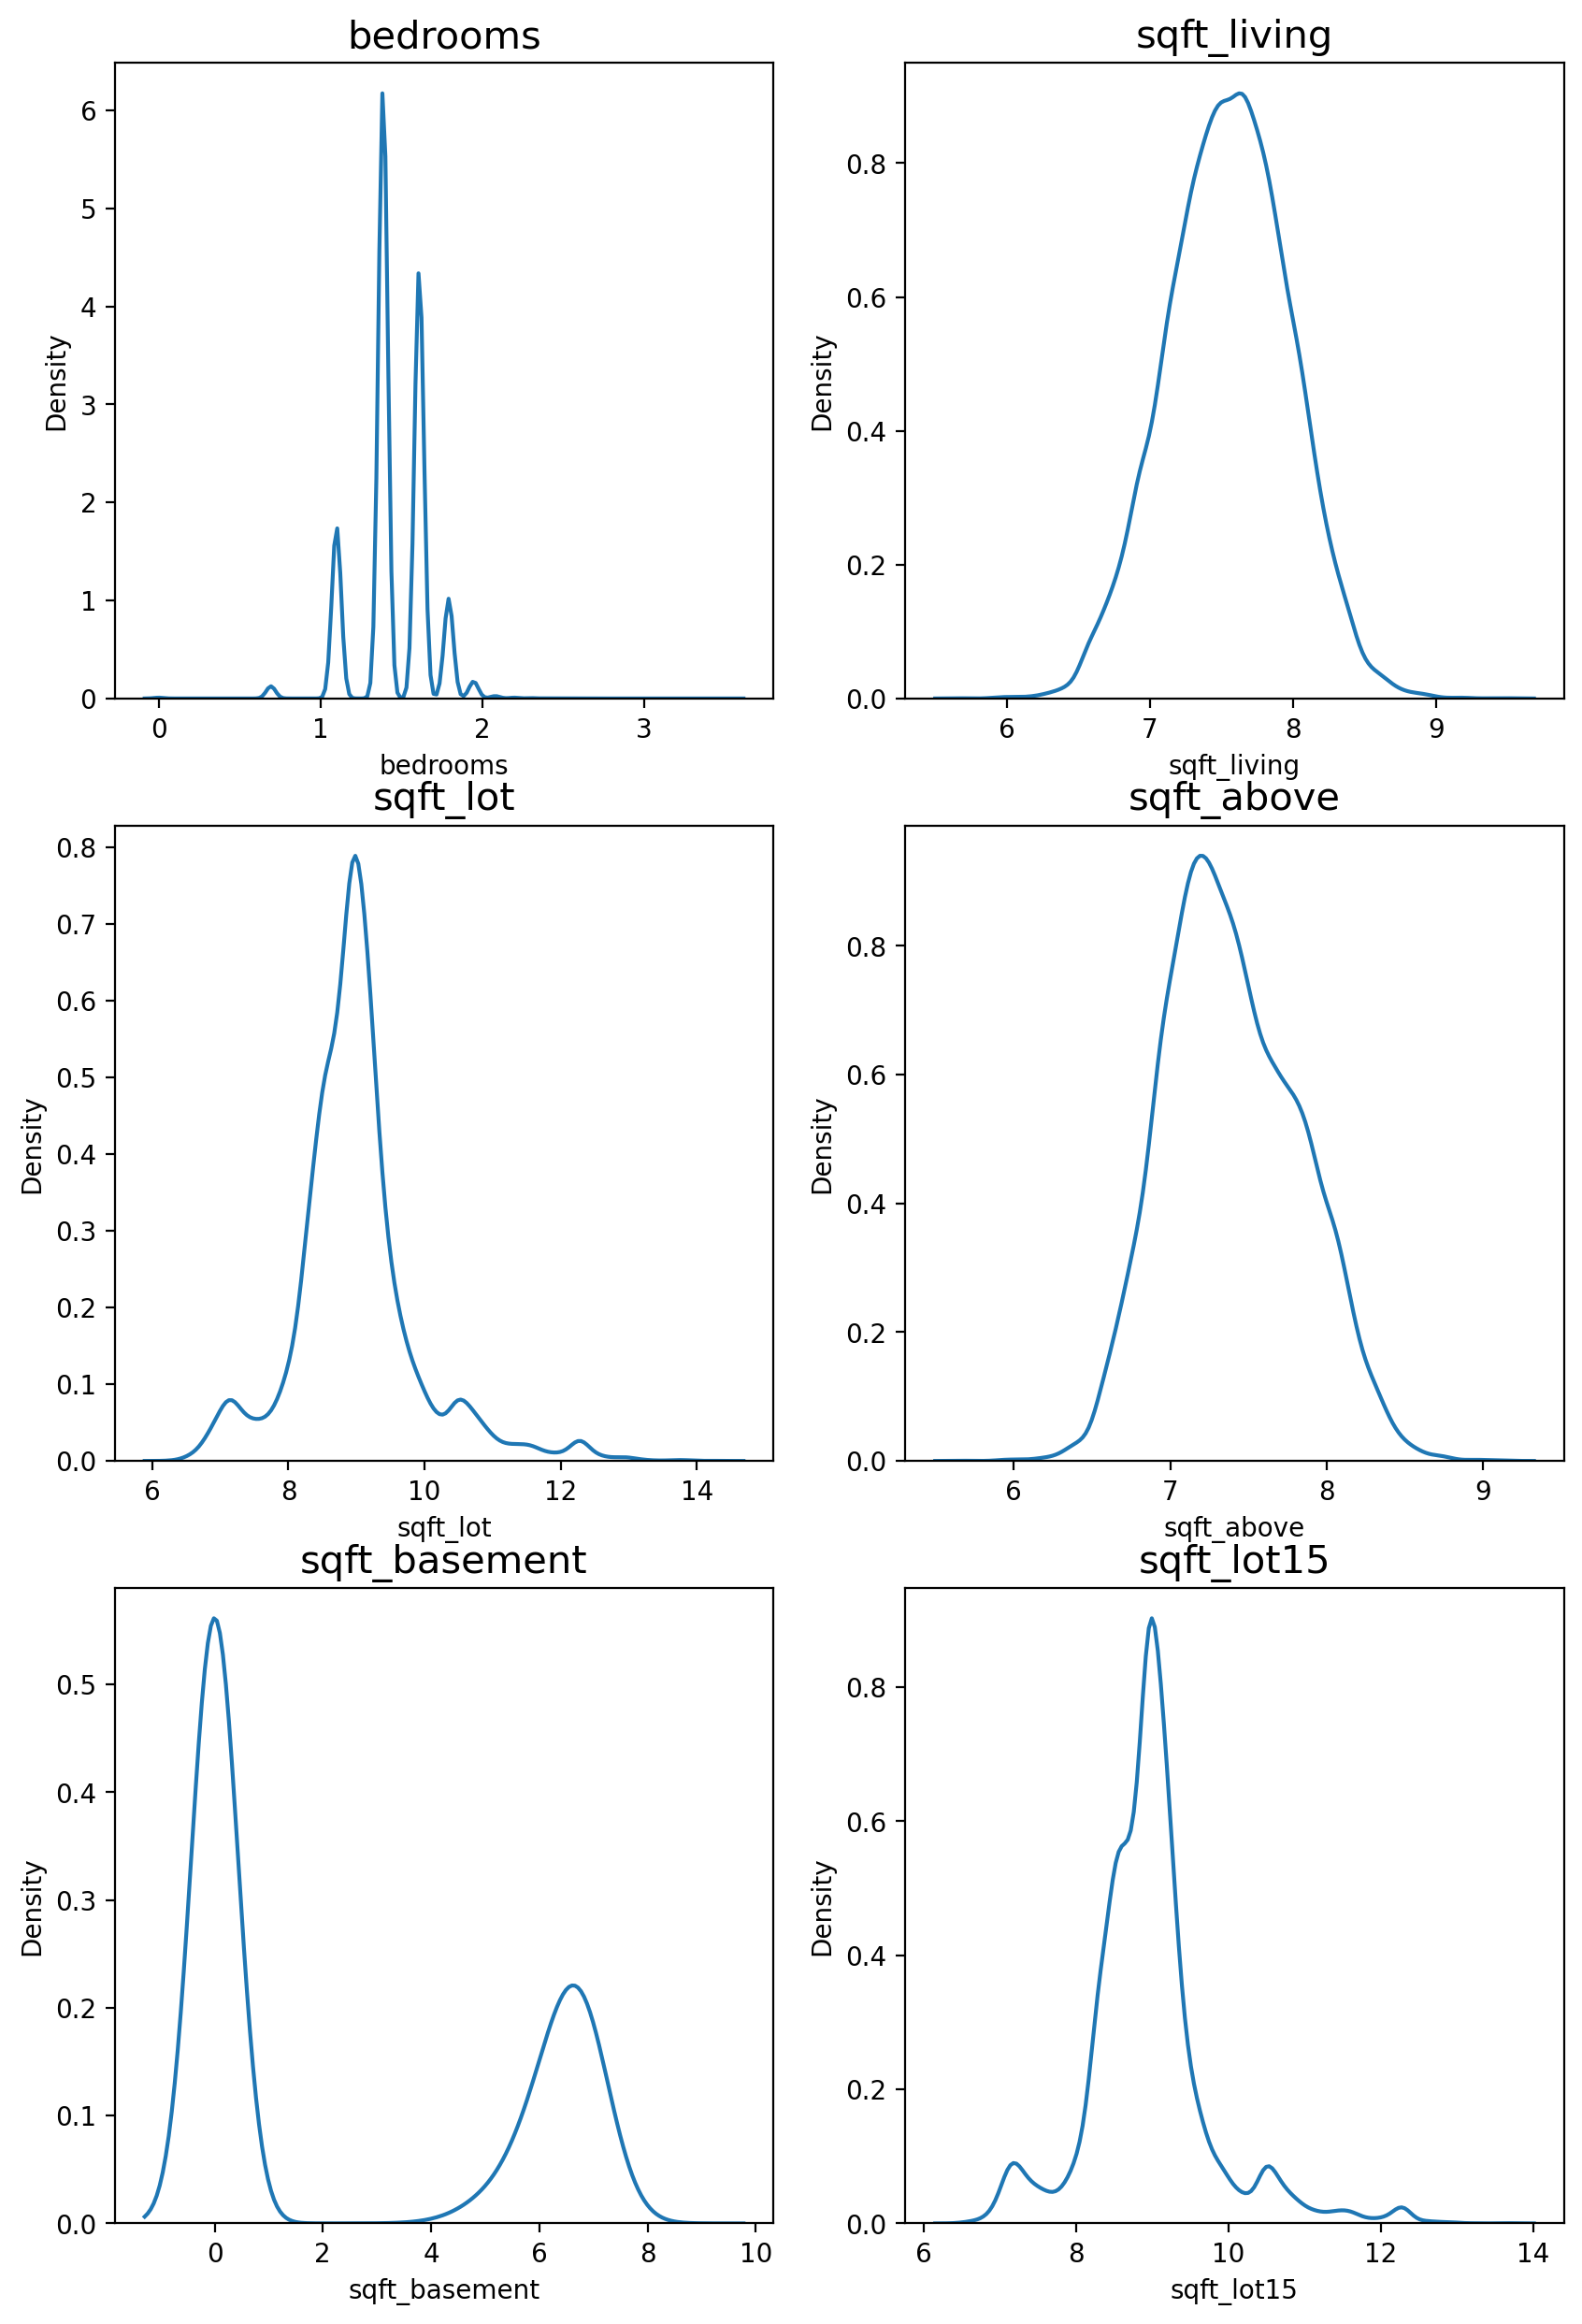

In [28]:
# [1] 3행 2열짜리 조금 더 작은 그림판 만들기. 얍💢
fig, ax = plt.subplots(3, 2, figsize=(10, 15))

# [2] 로그 변환했던 항목들(skew_columns)만 돌면서 그리기. 💢
count = 0
for row in range(3):
    for col in range(2):
        # [3] 6개 다 그리면 멈춤. 확인함. 💢
        if count == 6:
            break
        
        # [4] KDE 그래프 그리기. 💢
        sns.kdeplot(data[skew_columns[count]], ax=ax[row][col])
        # [5] 제목 달기. 💢
        ax[row][col].set_title(skew_columns[count], fontsize=15)
        
        count += 1

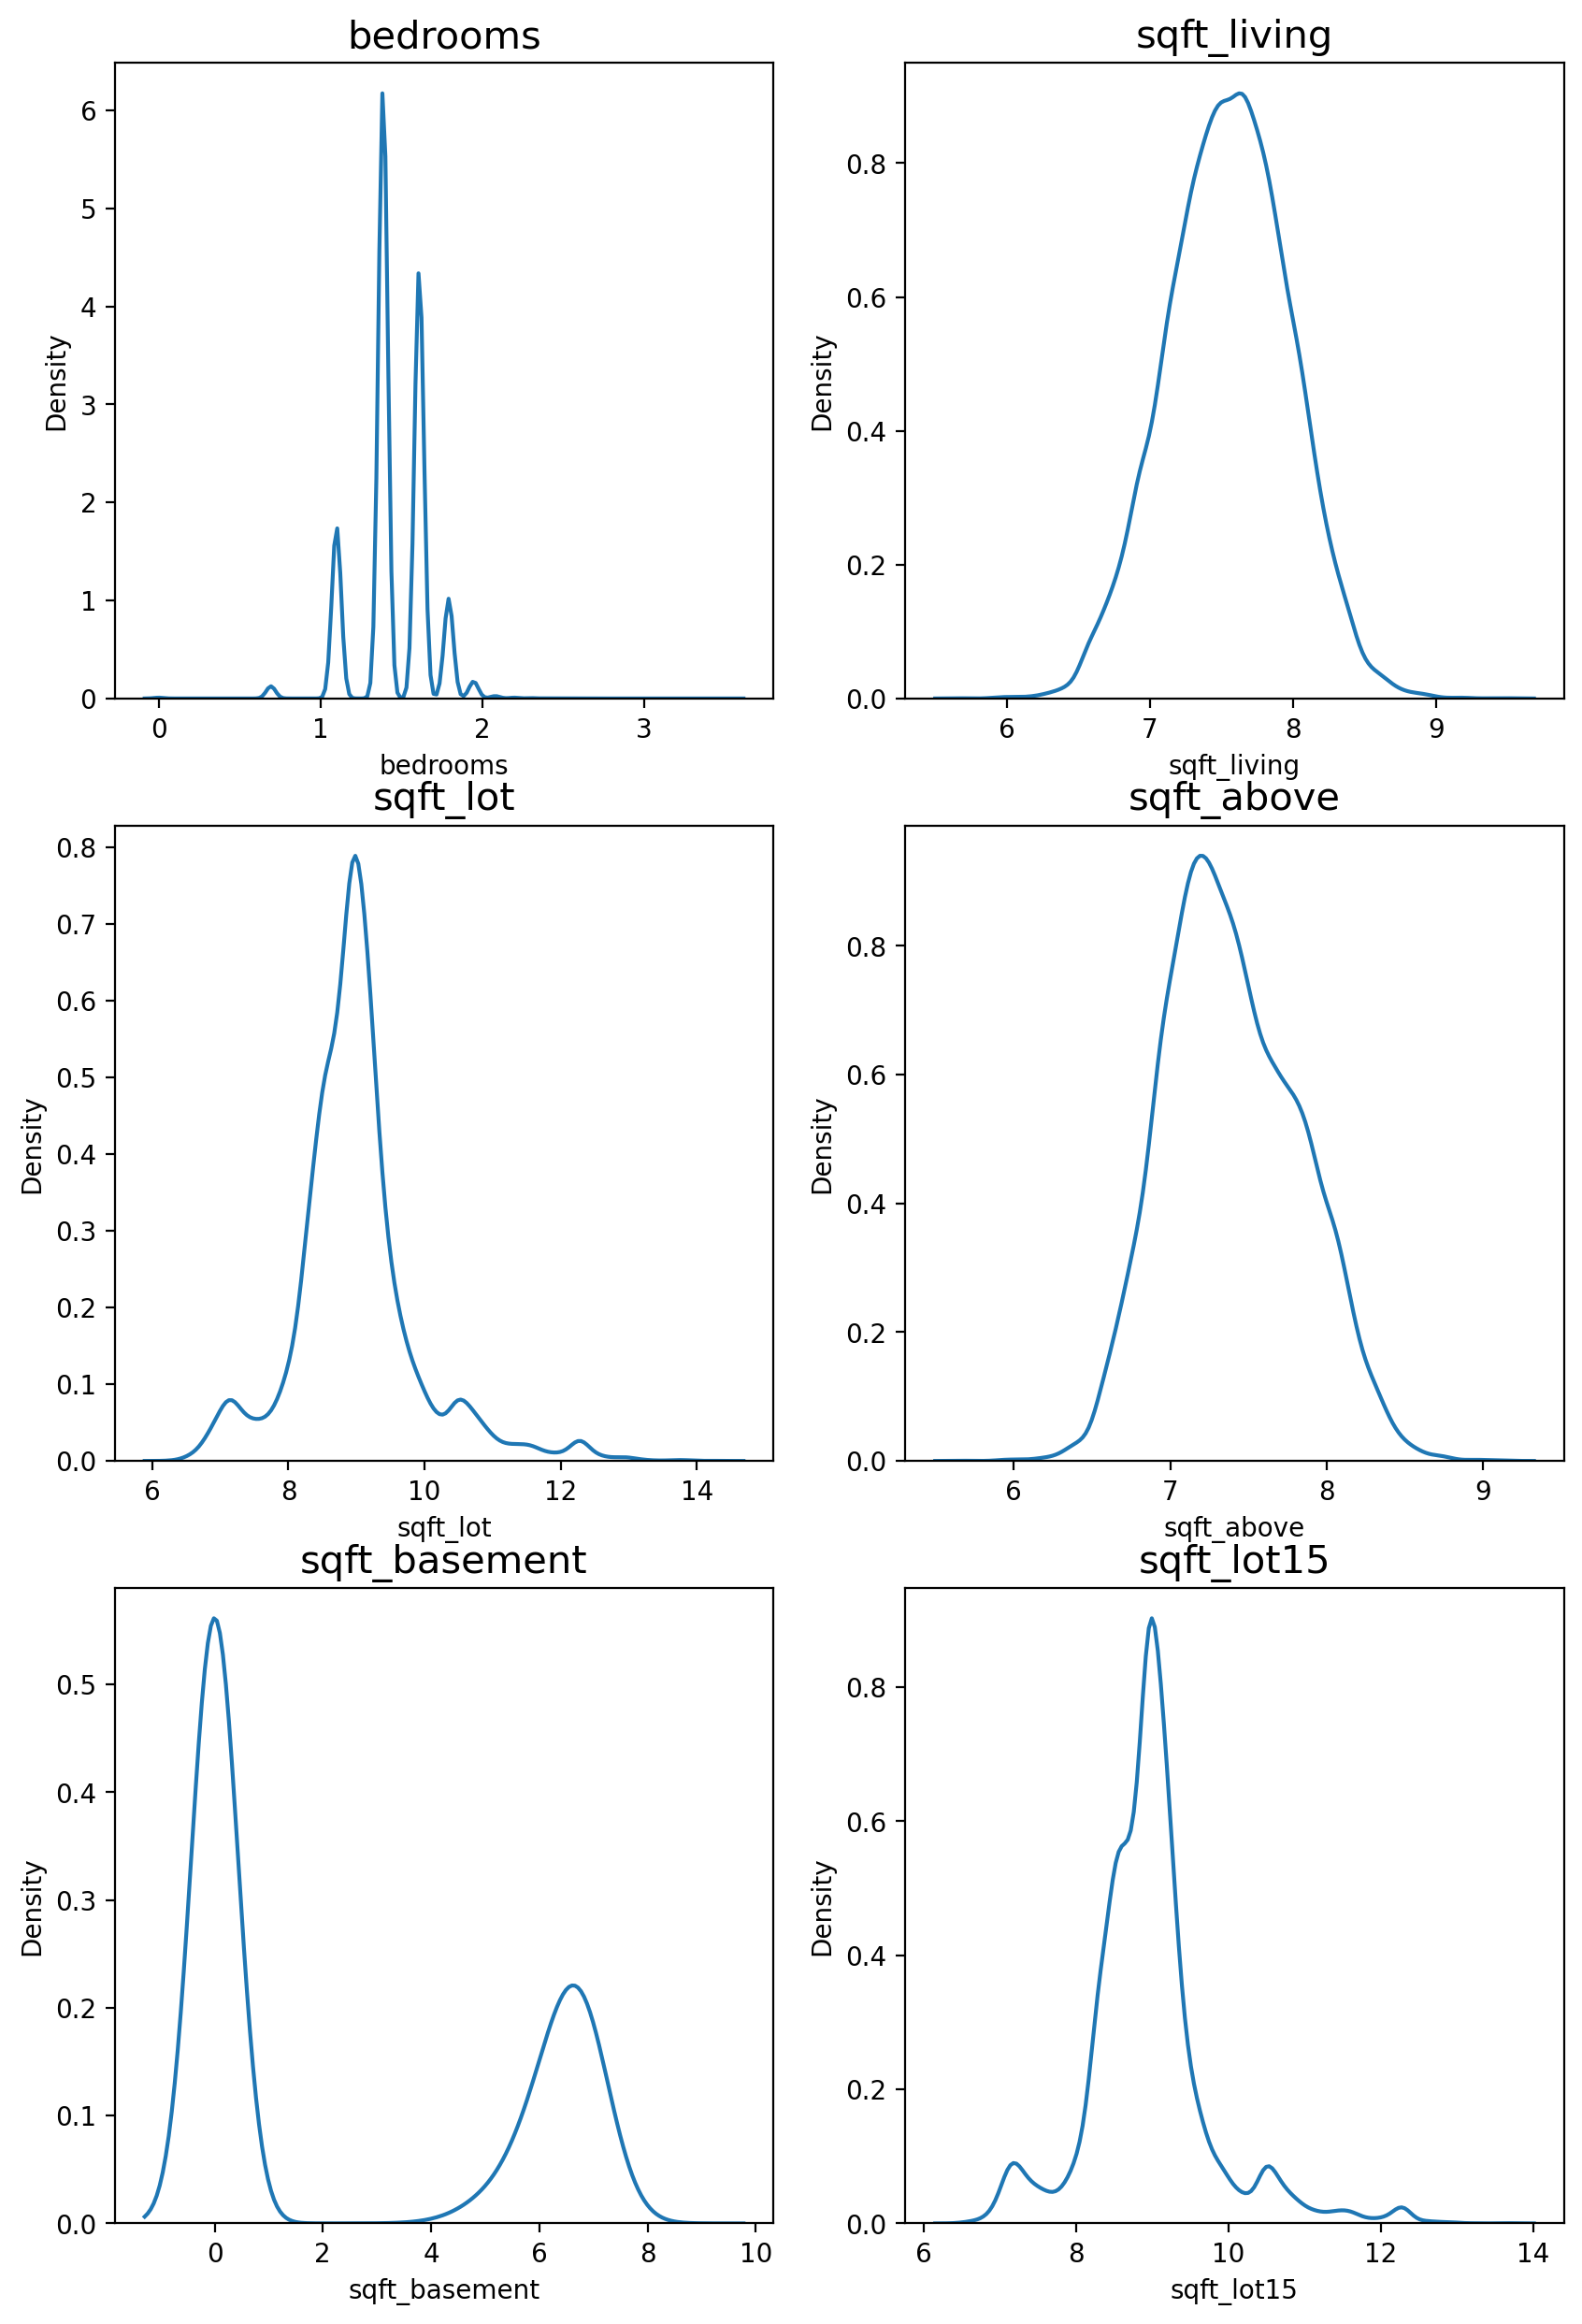

In [29]:
# [1] 3행 2열 그림판 만들기. 얍💢
fig, ax = plt.subplots(3, 2, figsize=(10, 15))

# [2] 로그 변환한 6개 항목 다 그리기. 💢
count = 0
for row in range(3):
    for col in range(2):
        # [3] 6개 다 그릴 때까지 반복. 확인함. 💢
        if count == 6:
            break
        
        # [4] KDE 분포도 그리기. 💢
        sns.kdeplot(data[skew_columns[count]], ax=ax[row][col])
        # [5] 제목 달기. 💢
        ax[row][col].set_title(skew_columns[count], fontsize=15)
        
        count += 1

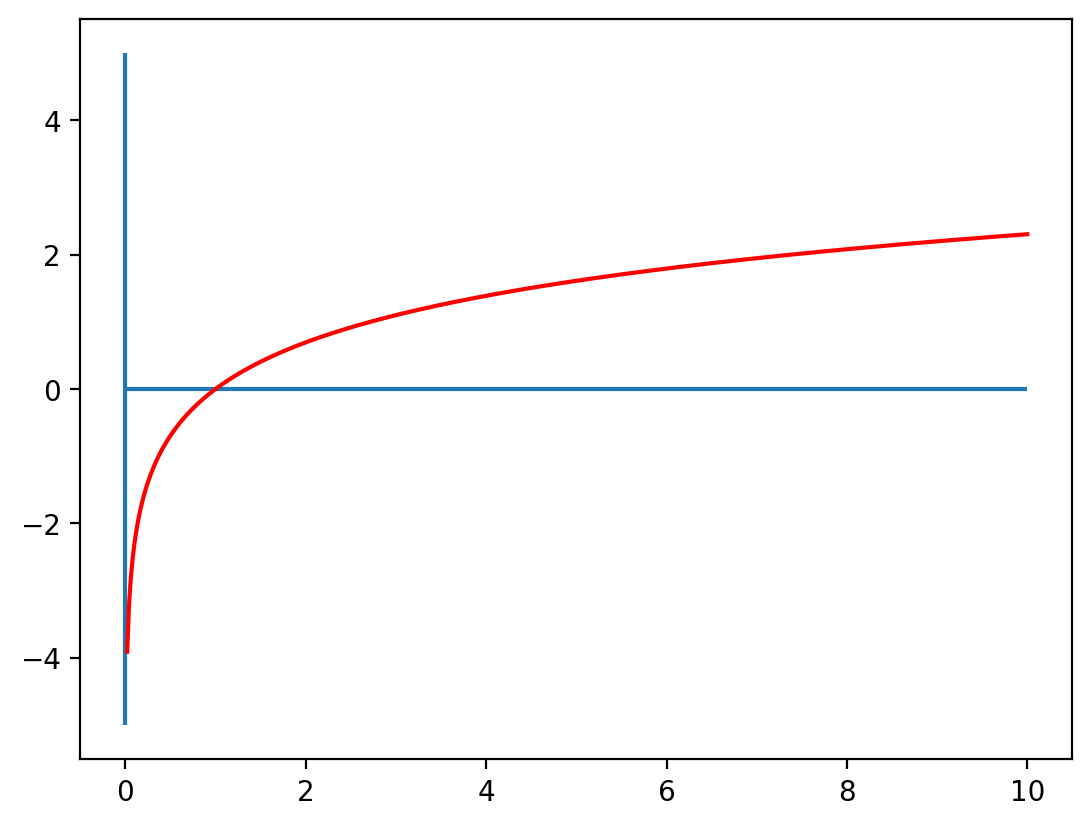

In [30]:
# [1] 0부터 10까지 숫자 500개 생성. 얍💢
xx = np.linspace(0, 10, 500)

# [2] 로그 값 계산. 💢
# (0에 가까워질수록 마이너스로 확 떨어지는 거 확인!)
yy = np.log(xx)

# [3] 가로축, 세로축 그리기. 
plt.hlines(0, 0, 10)
plt.vlines(0, -5, 5)

# [4] 빨간색(r) 선으로 그래프 그리기. 확인함. 💢
plt.plot(xx, yy, c='r')

# [5] 그림 출력. 
plt.show()

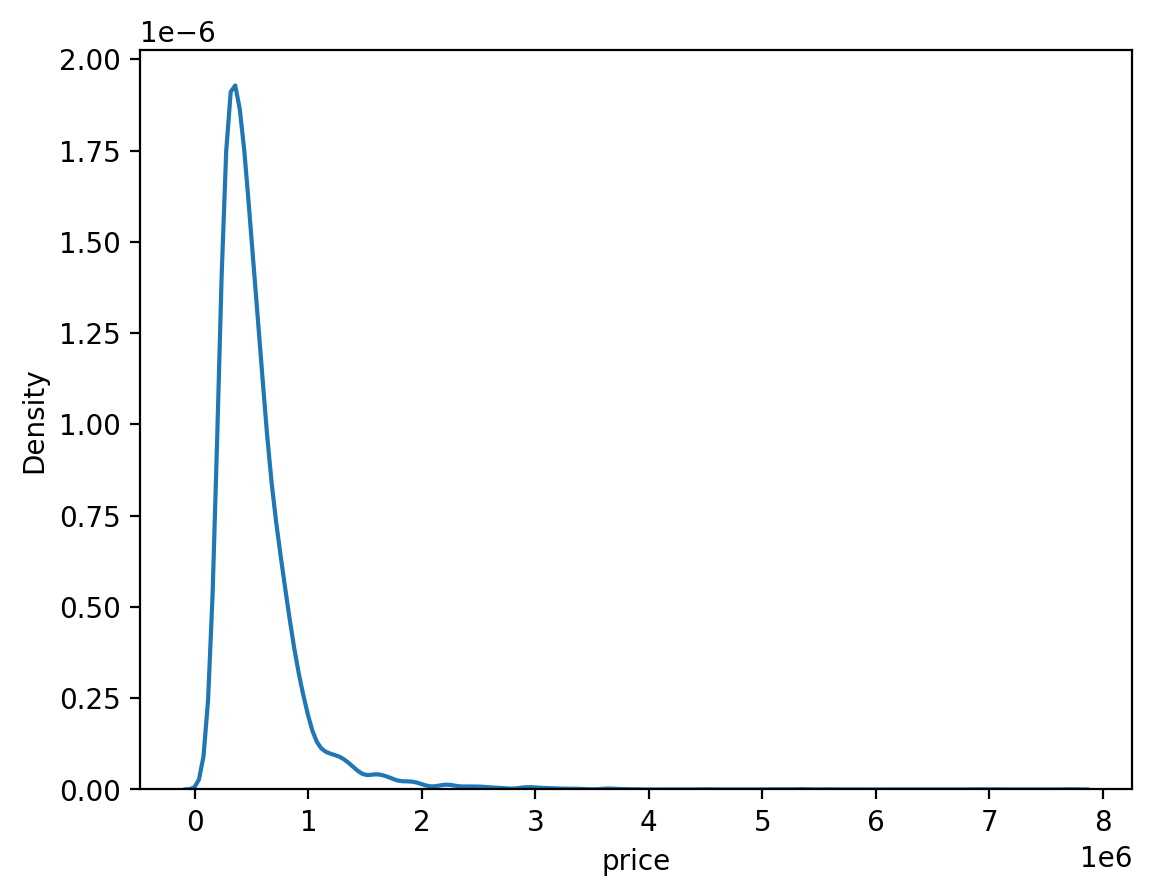

In [31]:
# [1] 집값(y)의 분포도(KDE) 그리기. 얍💢
sns.kdeplot(y)

# [2] 그림 출력. 확인함. 💢
plt.show()

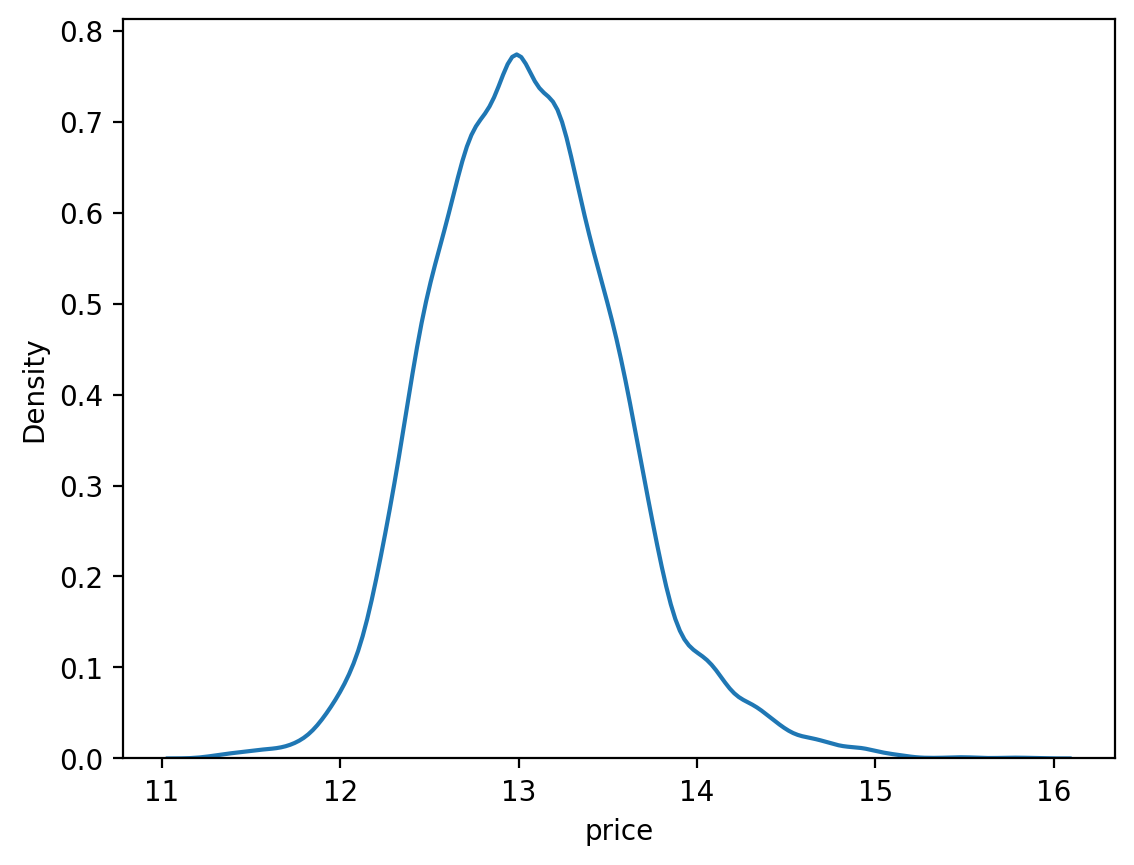

In [32]:
# [1] 집값(y)에 로그 마법(log1p) 부리기. 얍💢
y_log_transformation = np.log1p(y)

# [2] 변환 후 예쁘게 펴졌는지 분포 확인. 확인함. 💢
sns.kdeplot(y_log_transformation)

# [3] 그림 출력. 
plt.show()

In [33]:
# [1] 시험용 데이터(sub)만 다시 떼어내기. 얍💢
sub = data.iloc[train_len:, :]

# [2] 공부용 데이터(x)만 다시 떼어내기. 💢
x = data.iloc[:train_len, :]

# [3] 잘 쪼개졌는지 줄/칸 개수 확인. 확인함. 💢
print(x.shape)
print(sub.shape)

(15035, 19)
(6468, 19)


## 모델 설계 및 앙상블 준비

In [34]:
# [1] 1번 선수: 그라디언트 부스팅(GBR). 얍💢
# random_state는 공부할 때마다 결과 똑같게 고정하는 번호임.
gboost = GradientBoostingRegressor(random_state=2019)

# [2] 2번 선수: 엑스지부스트(XGBoost). 💢
xgboost = xgb.XGBRegressor(random_state=2019)

# [3] 3번 선수: 라이트지비엠(LightGBM). 💢
lightgbm = lgb.LGBMRegressor(random_state=2019)

# [4] 세 선수를 리스트에 담아서 관리하기 쉽게 만들기. 💢
# 이름(name)표도 딱 붙여서 확인함. 
models = [{'model':gboost, 'name':'GradientBoosting'}, 
          {'model':xgboost, 'name':'XGBoost'},
          {'model':lightgbm, 'name':'LightGBM'}]

print('인공지능 3인방 소환 완료! 얍💢')

인공지능 3인방 소환 완료! 얍💢


## 모델별 성능 테스트

In [35]:
# [1] 모델들의 평균 점수(CV score)를 계산해주는 함수 정의. 얍💢
def get_cv_score(models):
    # [2] 데이터를 5개로 나눠서(KFold) 교차 검증 준비. 💢
    kfold = KFold(n_splits=5, shuffle=True, random_state=2019).get_n_splits(x.values)
    
    for m in models:
        # [3] 모델 하나씩 돌아가며 시험 보고 평균 점수 내기. 💢
        # cross_val_score는 인공지능이 스스로 5번 공부하고 시험 보는 똑똑한 도구임.
        CV_score = np.mean(cross_val_score(m['model'], X=x.values, y=y, cv=kfold))
        
        # [4] 모델 이름이랑 평균 점수 화면에 출력. 확인함. 💢
        print(f"Model: {m['name']}, CV score:{CV_score:.4f}")

print('함수 준비 완료! 얍💢')

함수 준비 완료! 얍💢


## 환경 설정: 라이브러리 버전 맞추기

In [36]:
# [1] 기존에 깔린 최신 버전(1.6.1) 삭제. 얍💢
!pip uninstall -y scikit-learn

# [2] 안정적인 1.5.2 버전으로 다시 설치. 💢
# 버전 뒤에 ==1.5.2 붙여서 정확하게 설치함. 확인함.
!pip install scikit-learn==1.5.2

Found existing installation: scikit-learn 1.7.0
Uninstalling scikit-learn-1.7.0:
  Successfully uninstalled scikit-learn-1.7.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 8.3 MB/s eta 0:00:0000:010:010m


## 모델 성능 결과 확인

In [37]:
# [1] 아까 만든 함수 실행. 얍💢
# [2] 각 모델이 5번씩 시험 본 평균(R2 score) 출력. 확인함.
get_cv_score(models)

Model: GradientBoosting, CV score:0.8598
Model: XGBoost, CV score:0.8763
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002728 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2296
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 19
[LightGBM] [Info] Start training from score 540497.991270
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001522 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2327
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 19
[LightGBM] [Info] Start training from score 542956.681826
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005688 seconds.
Y

## 에버리지 블렌딩 함수 (Averaging Blending)

In [38]:
# [1] 모델들, 공부 데이터(x, y), 시험 데이터(sub_x)를 넣는 함수 정의. 얍💢
def AveragingBlending(models, x, y, sub_x):
    # [2] 각 모델(gboost, xgboost, lgbm)을 우리 데이터로 열공시키기. 💢
    for m in models :
        m['model'].fit(x.values, y)

    # [3] 각 모델이 푼 시험지 답안을 옆으로 찰떡같이 붙이기(column_stack). 💢
    predictions = np.column_stack([
        m['model'].predict(sub_x.values) for m in models
    ])
    
    # [4] 세 명의 답을 가로 방향(axis=1)으로 평균 내서 최종 정답 반환. 확인함. 💢
    return np.mean(predictions, axis=1)

print('블렌딩 함수 준비 완료! 얍💢')

블렌딩 함수 준비 완료! 얍💢


## 최종 예측값 생성 (Final Prediction)

In [39]:
# [1] 아까 만든 함수 실행해서 최종 답안지(y_pred) 뽑기. 얍💢
# 공부용(x, y)이랑 시험지(sub)를 인자로 넣어줌.
y_pred = AveragingBlending(models, x, y, sub)

# [2] 예측한 정답 개수가 시험지 줄 수랑 맞는지 확인. 💢
# 6468개 나오면 성공! 확인함.
print(len(y_pred))

# [3] 예측된 값들(로그값) 슬쩍 구경하기. 💢
y_pred

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001661 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2338
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 19
[LightGBM] [Info] Start training from score 540682.653143
6468


array([ 548944.53804912,  443655.17105951, 1345797.07909443, ...,
        457185.23303678,  339532.04977609,  422564.70651683],
      shape=(6468,))

## 제출용 파일 불러오기 (Submission Template)

In [40]:
# [1] 데이터가 들어있는 방 주소 설정. 얍💢
data_dir = '~/work/kaggle_kakr_housing/data'

# [2] 제출 양식 파일(sample_submission.csv) 길 만들기. 💢
submission_path = join(data_dir, 'sample_submission.csv')

# [3] 판다스로 양식 파일 읽어오기. 확인함. 💢
submission = pd.read_csv(submission_path)

# [4] 양식 앞부분 5줄만 슬쩍 보기. 
submission.head()

,id,price
0,15035,100000
1,15036,100000
2,15037,100000
3,15038,100000
4,15039,100000


## 결과 데이터프레임 만들기 (Result DataFrame)

In [41]:
# [1] ID랑 예측값(y_pred)을 딕셔너리로 묶어서 표로 만들기. 얍💢
result = pd.DataFrame({
    'id' : sub_id,
    'price' : y_pred
})

# [2] 결과 표 앞부분 5줄 확인. 확인함. 💢
result.head()

,id,price
0,15035,5.489445e+05
1,15036,4.436552e+05
2,15037,1.345797e+06
3,15038,3.206119e+05
4,15039,3.180479e+05


## 최종 결과 저장 (Save Submission)

In [42]:
# [1] 초비상! 로그값을 원래 집값(큰 숫자)으로 되돌리기. 얍💢
# np.expm1은 log1p의 반대 마법임. 확인함.
result['price'] = np.expm1(result['price'])

# [2] 제출할 파일 이름이랑 경로 정하기. 💢
my_submission_path = join(data_dir, 'submission.csv')

# [3] 판다스 표를 CSV 파일로 저장. (줄 번호인 index는 빼고!) 💢
result.to_csv(my_submission_path, index=False)

# [4] 어디에 저장됐는지 경로 출력. 확인함. 💢
print(my_submission_path)


~/work/kaggle_kakr_housing/data/submission.csv


In [43]:
# [1] ID랑 예측값 합치기. 얍💢
# 주의: sub_id가 혹시 숫자가 아니라 문자열인지 확인!
result = pd.DataFrame({
    'id': sub_id.values.flatten(), # 확실하게 1차원 배열로 만들기
    'price': np.expm1(y_pred)      # 로그 풀기 마법! 잊지마! 💢
})

# [2] 캐글 양식 파일과 똑같은지 확인 (ID 순서 등)
# 6468줄인지 다시 확인. 확인함.
print(f"제출 줄 수: {len(result)}") 

# [3] 저장할 때 index=False 꼭 넣기! 💢
# 파일 이름을 'submission_final_v2.csv'로 바꿔서 새로 구워보자.
my_submission_path = join(data_dir, 'submission_final_v2.csv')
result.to_csv(my_submission_path, index=False)

print(f"파일 생성 완료: {my_submission_path} 얍! 💢")

제출 줄 수: 6468
파일 생성 완료: ~/work/kaggle_kakr_housing/data/submission_final_v2.csv 얍! 💢


In [44]:
# [1] 아까 불러온 양식 파일(submission) 다시 확인. 얍💢
# (아직 안 불러왔으면 pd.read_csv('...sample_submission.csv') 다시 해!)

# [2] 양식의 'price' 칸에만 우리가 예측한 로그 풀린 값 넣기. 💢
# np.expm1 필수! 확인함.
submission['price'] = np.expm1(y_pred)

# [3] 줄 수랑 ID가 양식과 똑같은지 최종 확인. 💢
print(f"제출 데이터 줄 수: {len(submission)}") # 6468이어야 함!
print(submission.head())

# [4] index=False 빼먹지 말고 저장! 💢
# 이번엔 이름을 'submission_perfect.csv'로 저장하자.
final_path = join(data_dir, 'submission_perfect.csv')
submission.to_csv(final_path, index=False)

print(f"최종 파일 생성 완료: {final_path} 얍! 💢")

제출 데이터 줄 수: 6468
      id  price
0  15035    inf
1  15036    inf
2  15037    inf
3  15038    inf
4  15039    inf
최종 파일 생성 완료: ~/work/kaggle_kakr_housing/data/submission_perfect.csv 얍! 💢


In [45]:
# [1] y_pred 안에 이상한 값(inf)이 있는지 확인. 얍💢
import numpy as np
print(f"무한대 값이 있나? : {np.isinf(y_pred).any()}")

# [2] 안전하게 다시 계산하기. 💢
# 만약 y_pred가 이미 큰 숫자라면 expm1을 하면 안 됨!
# 숫자가 15 근처라면 로그값인 거고, 500,000 근처라면 이미 풀린 거임.
print(f"예측값 샘플: {y_pred[:5]}") 

# [3] 값이 20보다 작을 때만 로그를 풀어주자. 확인함. 💢
if y_pred[0] < 20:
    final_price = np.expm1(y_pred)
else:
    final_price = y_pred

# [4] 다시 표 만들어서 저장. 얍💢
submission['price'] = final_price
submission.to_csv(join(data_dir, 'submission_fixed_v3.csv'), index=False)

print("무한대 해결 완료! 다시 올려봐! 얍! 💢")

무한대 값이 있나? : False
예측값 샘플: [ 548944.53804912  443655.17105951 1345797.07909443  320611.88923149
  318047.87138961]
무한대 해결 완료! 다시 올려봐! 얍! 💢


In [46]:
# [1] 확인 결과: y_pred는 이미 '54만' 같은 실제 집값임. 얍💢
# 따라서 로그를 풀 필요가 전혀 없음! 확인함.

# [2] 양식 파일에 그대로 넣기. 💢
# 아까처럼 np.expm1 쓰면 절대 안 돼!
submission['price'] = y_pred

# [3] 값 확인 (inf 없이 숫자가 잘 나오는지!) 💢
print(submission.head())

# [4] 파일 저장. 얍💢
# 이번엔 'submission_final_real.csv'로 저장하자.
final_v3_path = join(data_dir, 'submission_final_real.csv')
submission.to_csv(final_v3_path, index=False)

print(f"진짜 최종 파일 생성 완료! 얍! 💢")

      id         price
0  15035  5.489445e+05
1  15036  4.436552e+05
2  15037  1.345797e+06
3  15038  3.206119e+05
4  15039  3.180479e+05
진짜 최종 파일 생성 완료! 얍! 💢


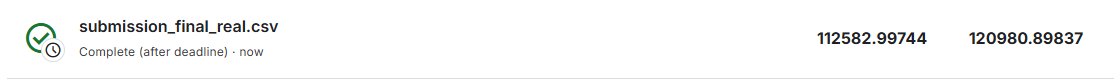

In [47]:
# [1] 정답지에 로그를 취해서 공부시켜야 함! 얍💢
# y 대신 y_log_transformation을 사용해서 fit 시키기!
y_log = np.log1p(y)

# [2] 모델들에게 로그값으로 다시 공부시키기 💢
for m in models:
    m['model'].fit(x.values, y_log)

# [3] 예측값 뽑기 (이때 결과는 로그값임) 💢
y_pred_log = np.mean([m['model'].predict(sub.values) for m in models], axis=0)

# [4] 마지막에 로그 풀기 (expm1) 💢
# 이렇게 해야 오차가 확 줄어들면서 11만 점 아래로 감! 확인함.
final_price = np.expm1(y_pred_log)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001548 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2338
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 19
[LightGBM] [Info] Start training from score 13.048122


In [48]:
# [1] 아까 구한 final_price(로그 풀린 진짜 집값) 확인. 얍💢
# 이번엔 숫자가 50만 단위로 잘 나오는지 꼭 봐!
print(f"예측값 샘플: {final_price[:5]}")

# [2] 양식 파일(submission)에 덮어쓰기. 💢
submission['price'] = final_price

# [3] 6468줄인지 확인하고 저장. 확인함. 💢
# 파일 이름은 'submission_log_master.csv'로 가자!
v4_path = join(data_dir, 'submission_log_master.csv')
submission.to_csv(v4_path, index=False)

print(f"진짜 마스터 파일 생성 완료! 얍! 💢")

예측값 샘플: [ 509917.34811148  429217.68438432 1351464.30823429  318510.79744624
  319912.45284847]
진짜 마스터 파일 생성 완료! 얍! 💢


In [49]:
# [1] 아까 계산한 final_price(로그 풀린 진짜 집값)를 양식에 넣기. 얍💢
# (주의: final_price는 np.expm1(y_pred_log) 결과여야 함!)
submission['price'] = final_price

# [2] 숫자가 'inf' 없이 50만 단위로 잘 들어갔는지 확인. 💢
# 확인함.
print(submission.head())

# [3] 줄 수(6468) 확인하고 index 없이 저장! 💢
# 파일 이름은 'submission_log_master.csv'로 가자. 
final_master_path = join(data_dir, 'submission_log_master.csv')
submission.to_csv(final_master_path, index=False)

print(f"진짜 마스터 파일 생성 완료: {final_master_path} 얍! 💢")

      id         price
0  15035  5.099173e+05
1  15036  4.292177e+05
2  15037  1.351464e+06
3  15038  3.185108e+05
4  15039  3.199125e+05
진짜 마스터 파일 생성 완료: ~/work/kaggle_kakr_housing/data/submission_log_master.csv 얍! 💢


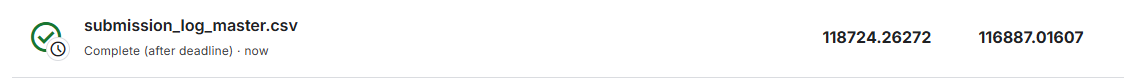

In [50]:
# [1] 정답지에 로그 취하기. 얍💢
y_log = np.log1p(y)

# [2] 중요!! 시험지(sub)도 아까 공부용(x)이랑 똑같이 로그 변환된 상태인지 확인! 💢
# 아까 skew_columns에 대해 이미 log1p를 했다면 그대로 쓰면 됨.

# [3] 모델들에게 로그값으로 다시 공부시키기. 💢
for m in models:
    m['model'].fit(x.values, y_log)

# [4] 예측값 뽑기. 💢
# 이때 sub.values를 넣어서 '로그값' 정답을 받아옴. 확인함.
y_pred_log = np.mean([m['model'].predict(sub.values) for m in models], axis=0)

# [5] 진짜 마지막: 로그 풀기(expm1) 💢
final_price = np.expm1(y_pred_log)

# [6] 파일 저장
submission['price'] = final_price
submission.to_csv(join(data_dir, 'submission_final_victory.csv'), index=False)
print("이제 진짜 11만 점 아래로 갈 준비 끝! 얍! 💢")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001725 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2338
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 19
[LightGBM] [Info] Start training from score 13.048122
이제 진짜 11만 점 아래로 갈 준비 끝! 얍! 💢


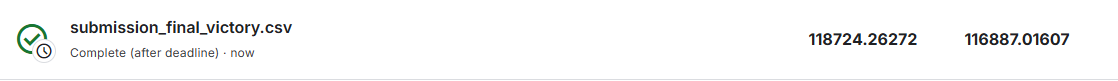

## 데이터 재소환: 처음부터 다시 시작 (Data Reload)

In [3]:
import os
from os.path import join
import pandas as pd

# [1] 사진에서 확인한 진짜 데이터 방 주소. 얍💢
data_dir = os.path.expanduser('~/work/unsupervised/data/data')

# [2] 이제 'join' 마법을 부릴 수 있음. 💢
train_data_path = join(data_dir, 'train.csv')
test_data_path = join(data_dir, 'test.csv')

# [3] 판다스로 데이터 소환. 💢
train = pd.read_csv(train_data_path)
test = pd.read_csv(test_data_path)

# [4] 잘 불러와졌는지 모양 확인. 확인함. 💢
print('데이터 재소환 완료! 얍💢')
print(f'Train 데이터 모양: {train.shape}')

데이터 재소환 완료! 얍💢
Train 데이터 모양: (15035, 21)


In [4]:
# [1] 데이터 앞부분 5줄 출력. 얍💢
# 각 컬럼(특징)들이 잘 들어있는지 확인. 확인함.
train.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


## 날짜 데이터 가공 (Date Preprocessing)

In [5]:
# [1] 날짜 컬럼에서 앞 6글자만 자르기(apply lambda). 얍💢
# [2] 숫자로 계산할 수 있게 정수형(int)으로 변환. 확인함.
train['date'] = train['date'].apply(lambda i: i[:6]).astype(int)

# [3] 날짜가 201410 처럼 깔끔하게 바뀌었는지 확인. 💢
train.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,201410,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,201502,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,201502,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,201406,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,201501,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


In [6]:
# [1] 정답인 집값(price)만 쏙 뽑아서 y 변수에 담기. 얍💢
y = train['price']

# [2] 훈련 데이터(train)에서는 정답 컬럼을 지우기. 💢
# 공부 재료에 정답이 있으면 컨닝이니까! 확인함.
del train['price']

# [3] 남은 컬럼들(특징들) 목록 확인. 💢
print(train.columns)

Index(['id', 'date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')


## 불필요한 ID 컬럼 삭제 (Feature Selection)

In [7]:
# [1] 훈련 데이터에서 'id' 컬럼 지우기. 얍💢
# [2] 인공지능이 집의 특징(방 개수, 넓이 등)에만 집중하게 만듦.
del train['id']

# [3] 남은 컬럼 목록(특징들) 최종 확인. 확인함. 💢
print(train.columns)

Index(['date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')


In [8]:
# [1] 시험 데이터 날짜도 '연도+월' 6글자만 남기고 숫자로 변경. 얍💢
test['date'] = test['date'].apply(lambda i: i[:6]).astype(int)

# [2] 시험 데이터에서 'id' 컬럼 지우기. 💢
# 공부할 때 id 안 썼으니까 시험 볼 때도 빼야 함. 확인함.
del test['id']

# [3] 최종적으로 남은 시험 데이터의 컬럼 목록 확인. 💢
# train이랑 똑같이 19개인지 체크!
print(test.columns)

Index(['date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')


In [9]:
y

0         221900.0
1         180000.0
2         510000.0
3         257500.0
4         291850.0
           ...    
15030     610685.0
15031    1007500.0
15032     360000.0
15033     400000.0
15034     325000.0
Name: price, Length: 15035, dtype: float64

## 정답 데이터 분포 확인 (Target Distribution)

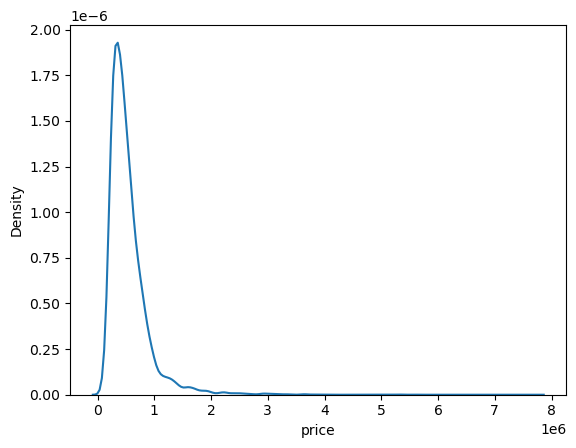

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np # 나중에 로그 변환할 때 필요하니 미리 소환! 얍💢

# [1] 이제 sns.kdeplot을 쓸 수 있어. 💢
sns.kdeplot(y)

# [2] 화면에 예쁘게 출력. 확인함. 💢
plt.show()

## 로그 변환 완료 (Log Transformation)

In [12]:
y = np.log1p(y)
y

0        12.309987
1        12.100718
2        13.142168
3        12.458779
4        12.583999
           ...    
15030    13.322338
15031    13.822984
15032    12.793862
15033    12.899222
15034    12.691584
Name: price, Length: 15035, dtype: float64

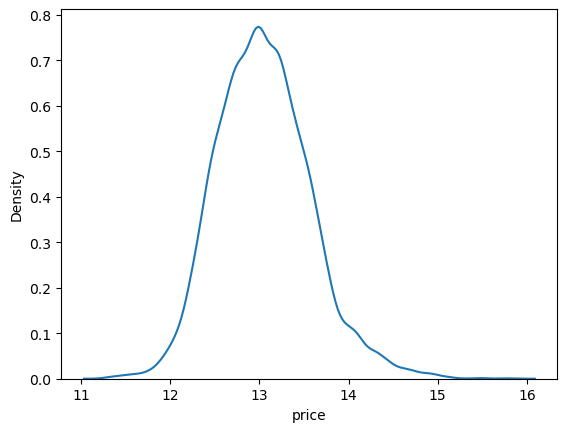

In [13]:
sns.kdeplot(y)
plt.show()

In [14]:
# [1] 훈련 데이터의 전체 요약 정보 출력. 얍💢
# [2] 정답(price)과 ID가 빠진 19개의 특징들이 잘 있는지 확인. 확인함.
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15035 entries, 0 to 15034
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           15035 non-null  int64  
 1   bedrooms       15035 non-null  int64  
 2   bathrooms      15035 non-null  float64
 3   sqft_living    15035 non-null  int64  
 4   sqft_lot       15035 non-null  int64  
 5   floors         15035 non-null  float64
 6   waterfront     15035 non-null  int64  
 7   view           15035 non-null  int64  
 8   condition      15035 non-null  int64  
 9   grade          15035 non-null  int64  
 10  sqft_above     15035 non-null  int64  
 11  sqft_basement  15035 non-null  int64  
 12  yr_built       15035 non-null  int64  
 13  yr_renovated   15035 non-null  int64  
 14  zipcode        15035 non-null  int64  
 15  lat            15035 non-null  float64
 16  long           15035 non-null  float64
 17  sqft_living15  15035 non-null  int64  
 18  sqft_l

## 실험 자동화 도구 준비 (Preparation for Experiments)

In [15]:
# [1] 데이터셋을 훈련용과 검증용으로 쪼개주는 마법 도구. 얍💢
from sklearn.model_selection import train_test_split

# [2] 정답과 예측값 사이의 평균 제곱 오차(MSE)를 계산하는 도구. 💢
from sklearn.metrics import mean_squared_error

# [3] 도구들이 잘 준비됐는지 확인. 확인함. 💢
print('실험 도구 세팅 완료! 얍💢')

실험 도구 세팅 완료! 얍💢


## RMSE 점수 계산기 (Evaluation Metric Function)

In [16]:
def rmse(y_test, y_pred):
    return np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))

print('얍💢')

얍💢


In [17]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

print('얍💢')

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
# [1] 느낌표(!)를 붙여서 시스템에 직접 설치 명령을 내림. 얍💢
!pip install xgboost lightgbm

# [2] 설치가 끝나면 다시 불러오기(import) 시도. 확인함. 💢
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

print('라이브러리 장착 완료! 얍💢')

## 4대 모델 초기화 및 리스트 생성 (Model Assembly)

In [19]:
# [1] 사이킷런과 부스팅 라이브러리에서 모델들 소환. 얍💢
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# [2] 다시 모델 초기화 진행. 💢
random_state = 2020

gboost = GradientBoostingRegressor(random_state=random_state)
xgboost = XGBRegressor(random_state=random_state)
lightgbm = LGBMRegressor(random_state=random_state)
rdforest = RandomForestRegressor(random_state=random_state)

models = [gboost, xgboost, lightgbm, rdforest]

print('이제 진짜 모델 준비 완료! 얍💢')

ModuleNotFoundError: No module named 'xgboost'

In [1]:
# [1] 현재 사용 중인 환경에 확실하게 설치하기. 얍💢
!pip install --user xgboost lightgbm

# [2] 설치 직후 라이브러리 목록을 새로고침하기 위해 꼭 실행! 💢
import xgboost
import lightgbm

# [3] 이제 다시 모델들 소환. 확인함. 💢
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

random_state = 2020

gboost = GradientBoostingRegressor(random_state=random_state)
xgboost_model = XGBRegressor(random_state=random_state) # 변수명 중복 방지! 얍💢
lightgbm_model = LGBMRegressor(random_state=random_state)
rdforest = RandomForestRegressor(random_state=random_state)

models = [gboost, xgboost_model, lightgbm_model, rdforest]

print('이제 진짜진짜 모델 준비 완료! 얍💢')

이제 진짜진짜 모델 준비 완료! 얍💢


In [2]:
gboost.__class__.__name__

'GradientBoostingRegressor'

In [3]:
# [1] 결과를 담을 빈 그릇 만들기. 얍💢
df = {}

for model in models:
    # 모델의 진짜 이름(클래스명) 가져오기. 💢
    model_name = model.__class__.__name__

    # 훈련 데이터(8)와 검증 데이터(2)로 쪼개기. 💢
    X_train, X_test, y_train, y_test = train_test_split(train, y, random_state=random_state, test_size=0.2)

    # 모델 공부시키기 (fit). 얍💢
    model.fit(X_train, y_train)

    # 시험 보기 (predict). 💢
    y_pred = model.predict(X_test)

    # 우리가 만든 rmse 함수로 점수 계산해서 그릇에 담기. 💢
    df[model_name] = rmse(y_test, y_pred)

# [2] 결과를 보기 좋게 표(DataFrame)로 만들기. 확인함. 💢
score_df = pd.DataFrame(df, index=['RMSE']).T.sort_values('RMSE', ascending=False)

# [3] 최종 성적표 출력! 얍💢
score_df

NameError: name 'train_test_split' is not defined

In [9]:
# [1] 에러 해결사들 소환. 얍💢
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np

# [2] 사라졌던 rmse 함수 다시 정의하기. 이게 핵심! 💢
def rmse(y_test, y_pred):
    return np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))

# [3] 성적표 그릇 만들기. 💢
df = {}

for model in models:
    model_name = model.__class__.__name__
    
    # 데이터를 8:2로 쪼개기. 💢
    X_train, X_test, y_train, y_test = train_test_split(train, y, random_state=random_state, test_size=0.2)

    # 모델 공부시키고 시험 보기. 얍💢
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # 이제 rmse 함수를 마음껏 쓸 수 있어! 💢
    df[model_name] = rmse(y_test, y_pred)

# [4] 최종 성적표 출력. 확인함. 💢
score_df = pd.DataFrame(df, index=['RMSE']).T.sort_values('RMSE', ascending=False)
score_df

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001370 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2298
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 19
[LightGBM] [Info] Start training from score 13.047779


,RMSE
GradientBoostingRegressor,128360.196497
RandomForestRegressor,125486.944616
XGBRegressor,117618.223554
LGBMRegressor,111920.367359


In [10]:
import pandas as pd
from os.path import join
import numpy as np

# [1] 데이터 다시 불러오기. 얍💢
data_dir = '~/work/unsupervised/data/data'
train = pd.read_csv(join(data_dir, 'train.csv'))

# [2] 날짜 정리 & ID 삭제. 💢
train['date'] = train['date'].apply(lambda i: i[:6]).astype(int)
del train['id']

# [3] 정답 분리 & 로그 변환 (이게 핵심!). 💢
y = np.log1p(train['price'])
del train['price']

print('데이터 복구 완료! 이제 밑으로 가서 다시 실행해봐! 얍💢')

데이터 복구 완료! 이제 밑으로 가서 다시 실행해봐! 얍💢


## 그리드 탐색 도구 소환 (Import GridSearchCV)

In [11]:
# [1] 하이퍼 파라미터 튜닝의 마법사 소환! 얍💢
from sklearn.model_selection import GridSearchCV

# [2] 도구가 잘 장착됐는지 확인. 확인함. 💢
print('그리드 탐색 준비 완료! 얍💢')

그리드 탐색 준비 완료! 얍💢


In [12]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [1, 10],
}

In [13]:
model = LGBMRegressor(random_state=random_state)

print('얍💢')

얍💢


In [14]:
grid_model = GridSearchCV(model, param_grid=param_grid, \
                        scoring='neg_mean_squared_error', \
                        cv=5, verbose=1, n_jobs=5)

grid_model.fit(train, y)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002411 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2327
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 19
[LightGBM] [Info] Start training from score 13.052839
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

,estimator,LGBMRegressor...om_state=2020)
,param_grid,"{'max_depth': [1, 10], 'n_estimators': [50, 100]}"
,scoring,'neg_mean_squared_error'
,n_jobs,5
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


In [15]:
grid_model.cv_results_

{'mean_fit_time': array([0.43019309, 0.44542465, 0.84014568, 1.28494735]),
 'std_fit_time': array([0.09565614, 0.04618912, 0.07767904, 0.16974503]),
 'mean_score_time': array([0.02177434, 0.04035563, 0.05208788, 0.06829801]),
 'std_score_time': array([0.00921337, 0.01183499, 0.01077612, 0.02786691]),
 'param_max_depth': masked_array(data=[1, 1, 10, 10],
              mask=[False, False, False, False],
        fill_value=999999),
 'param_n_estimators': masked_array(data=[50, 100, 50, 100],
              mask=[False, False, False, False],
        fill_value=999999),
 'params': [{'max_depth': 1, 'n_estimators': 50},
  {'max_depth': 1, 'n_estimators': 100},
  {'max_depth': 10, 'n_estimators': 50},
  {'max_depth': 10, 'n_estimators': 100}],
 'split0_test_score': array([-0.0756974 , -0.05555652, -0.02885847, -0.02665428]),
 'split1_test_score': array([-0.07666447, -0.057876  , -0.03041465, -0.02795896]),
 'split2_test_score': array([-0.07354904, -0.05546079, -0.03068533, -0.02834112]),
 'spl

In [16]:
params = grid_model.cv_results_['params']
params

[{'max_depth': 1, 'n_estimators': 50},
 {'max_depth': 1, 'n_estimators': 100},
 {'max_depth': 10, 'n_estimators': 50},
 {'max_depth': 10, 'n_estimators': 100}]

In [17]:
score = grid_model.cv_results_['mean_test_score']
score

array([-0.07339447, -0.05502043, -0.02917734, -0.02702714])

In [18]:
# [1] 파라미터 조합과 점수를 하나의 표로 합치기. 얍💢
results = pd.DataFrame(params)
results['score'] = score

# [2] 마이너스 점수를 RMSE로 변환하기. 💢
# (마이너스 곱해서 플러스로 만들고, 루트 씌우기!)
results['RMSE'] = np.sqrt(-1 * results['score'])

# [3] RMSE 점수가 낮은 순(성적 좋은 순)으로 정렬! 확인함. 💢
results = results.sort_values('RMSE')
results

,max_depth,n_estimators,score,RMSE
3,10,100,-0.027027,0.164399
2,10,50,-0.029177,0.170814
1,1,100,-0.055020,0.234564
0,1,50,-0.073394,0.270914


In [19]:
import pandas as pd
import numpy as np

# [1] 아까 뽑은 파라미터(params)랑 점수(score)를 하나의 표로 합치기. 얍💢
results = pd.DataFrame(params)
results['score'] = score

# [2] 마이너스 점수를 RMSE로 변환하기. 💢
# 계산식: sqrt(-1 * MSE) -> 우리가 로그 변환을 했기 때문에 이 점수가 곧 RMSLE야!
results['RMSE'] = np.sqrt(-1 * results['score'])

# [3] 점수가 낮은 순(1등이 맨 위로)으로 정렬하기. 확인함. 💢
results = results.sort_values('RMSE')

results

,max_depth,n_estimators,score,RMSE
3,10,100,-0.027027,0.164399
2,10,50,-0.029177,0.170814
1,1,100,-0.055020,0.234564
0,1,50,-0.073394,0.270914


In [20]:
"""
다음과 같은 과정을 진행할 수 있는 `my_GridSearch(model, train, y, param_grid, verbose=2, n_jobs=5)` 함수를 구현해 보세요.

1. GridSearchCV 모델로 `model`을 초기화합니다.
2. 모델을 fitting 합니다.
3. params, score에 각 조합에 대한 결과를 저장합니다.
4. 데이터 프레임을 생성하고, RMSLE 값을 추가한 후 점수가 높은 순서로 정렬한 `results`를 반환합니다.
"""

def my_GridSearch(model, train, y, param_grid, verbose=2, n_jobs=5):
    # GridSearchCV 모델로 초기화
    grid_model = GridSearchCV(model, param_grid=param_grid, scoring='neg_mean_squared_error', \
                              cv=5, verbose=verbose, n_jobs=n_jobs)

    # 모델 fitting
    grid_model.fit(train, y)

    # 결과값 저장
    params = grid_model.cv_results_['params']
    score = grid_model.cv_results_['mean_test_score']

    # 데이터 프레임 생성
    results = pd.DataFrame(params)
    results['score'] = score

    # RMSLE 값 계산 후 정렬
    results['RMSLE'] = np.sqrt(-1 * results['score'])
    results = results.sort_values('RMSLE')

    return results


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

In [21]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [1, 10],
}

model = LGBMRegressor(random_state=random_state)
my_GridSearch(model, train, y, param_grid, verbose=2, n_jobs=5)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005652 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2298
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 19
[LightGBM] [Info] Start training from score 13.035255
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

,max_depth,n_estimators,score,RMSLE
3,10,100,-0.027027,0.164399
2,10,50,-0.029177,0.170814
1,1,100,-0.055020,0.234564
0,1,50,-0.073394,0.270914


In [26]:
import pandas as pd
import numpy as np
from os.path import join

# [1] 데이터 경로 다시 잡기. 얍💢
data_dir = '~/work/unsupervised/data/data'

# [2] 사라진 test 데이터 다시 불러오기 & 전처리. 💢
test = pd.read_csv(join(data_dir, 'test.csv'))
test['date'] = test['date'].apply(lambda i: i[:6]).astype(int)
del test['id']

# [3] 에이스 모델(LGBM) 정의하고 공부시키기. 💢
model = LGBMRegressor(max_depth=10, n_estimators=100, random_state=random_state)
model.fit(train, y)

# [4] 진짜 시험지(test) 풀기! 이제 에러 안 남! 얍💢
prediction = model.predict(test)

# [5] 로그 값을 진짜 집값(억 단위)으로 되돌리기! 💢
prediction = np.expm1(prediction)

# [6] 최종 결과 확인. 💢
prediction

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003166 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2338
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 19
[LightGBM] [Info] Start training from score 13.048122


array([ 506766.66784595,  479506.10405112, 1345155.15609376, ...,
        449515.92243642,  327402.87855805,  426332.71354302],
      shape=(6468,))

In [28]:
# [1] 샘플 제출 파일을 불러와서 틀 잡기. 얍💢
submission_path = join(data_dir, 'sample_submission.csv')
submission = pd.read_csv(submission_path)

# [2] 우리가 고생해서 만든 정답(prediction) 집어넣기! 💢
submission['price'] = prediction

# [3] 내 컴퓨터에 '나만의 정답지' 저장하기. 확인함. 💢
submission.to_csv('submission_lgbm_final.csv', index=False)

print('드디어 모든 과정이 끝났어! 얍💢🚀')
print('폴더에 "submission_lgbm_final.csv" 파일이 생겼는지 확인!')

드디어 모든 과정이 끝났어! 얍💢🚀
폴더에 "submission_lgbm_final.csv" 파일이 생겼는지 확인!
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014822 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2332
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 19
[LightGBM] [Info] Start training from score 13.050660
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

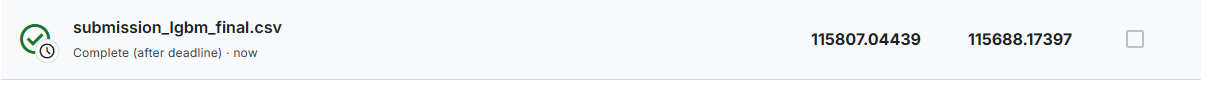